In [127]:
# Importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [128]:
# Loading the data

data = pd.read_csv("customer_segmentation.csv")

In [129]:
# Analysis Of The Data

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [130]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [131]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [132]:
data.shape

(2240, 29)

In [133]:
data.isnull().sum().sum()

np.int64(24)

In [134]:
data.dropna(inplace=True)

In [135]:
data.isnull().sum().sum()

np.int64(0)

In [136]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [137]:
data["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [138]:
data["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [139]:
# Data Preprocessing And Feature Engineering

data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"],dayfirst =True)

In [140]:
data.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

In [141]:
data["Age"] = 2026 - data["Year_Birth"]

In [142]:
data["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [143]:
data["Total_Children"] = data["Kidhome"] + data["Teenhome"]

In [144]:
data["Total_Children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [145]:
total_spend = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

In [146]:
data["Total_Spending"] = data[total_spend].sum(axis=1)

In [147]:
data["Total_Spending"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

In [148]:
data["Customer_Since"] = (pd.Timestamp("today") - data["Dt_Customer"]).dt.days

In [149]:
data["Customer_Since"]

0       4945
1       4395
2       4594
3       4421
4       4443
        ... 
2235    4663
2236    4301
2237    4437
2238    4438
2239    4904
Name: Customer_Since, Length: 2216, dtype: int64

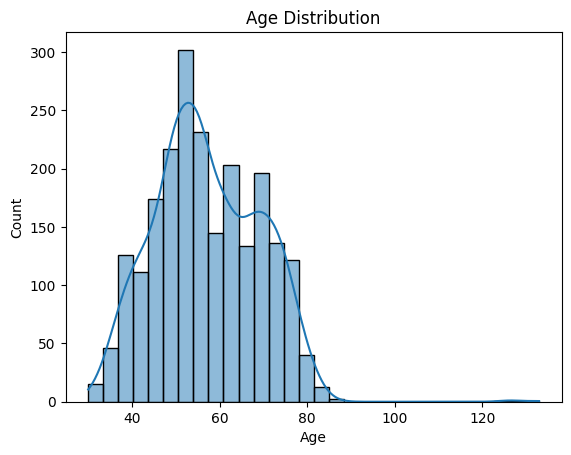

In [150]:
# More Analyization Of Data

sns.histplot(data["Age"], bins= 30, kde=True)
plt.title("Age Distribution")
plt.show()

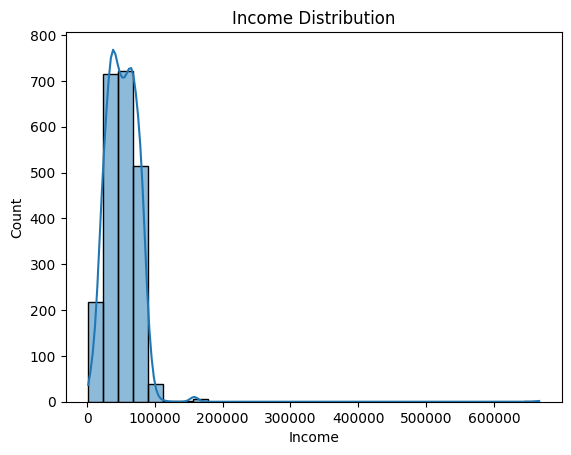

In [151]:
sns.histplot(data["Income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

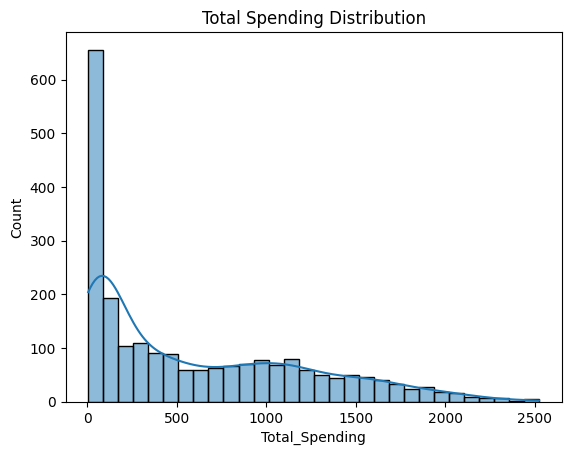

In [152]:
sns.histplot(data["Total_Spending"], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

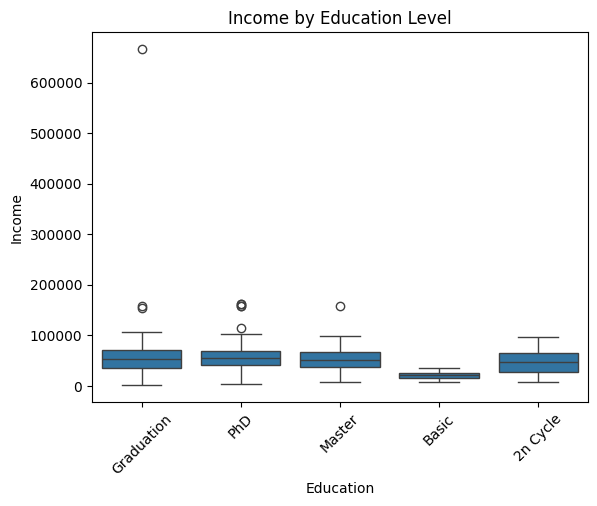

In [153]:
sns.boxplot(x="Education", y= "Income", data = data)
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

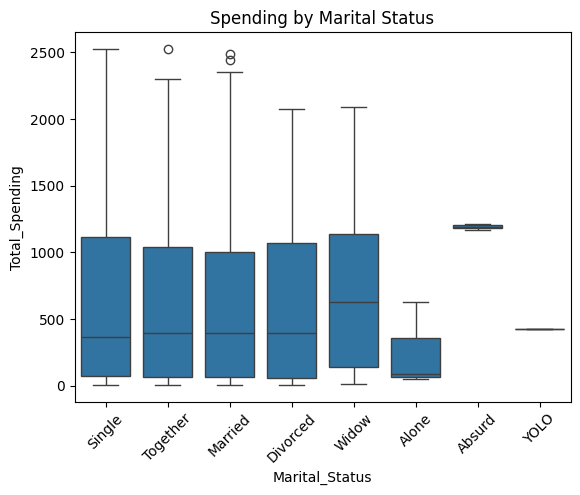

In [154]:
sns.boxplot(x= "Marital_Status", y= "Total_Spending", data = data)
plt.xticks(rotation = 45)
plt.title("Spending by Marital Status")
plt.show()

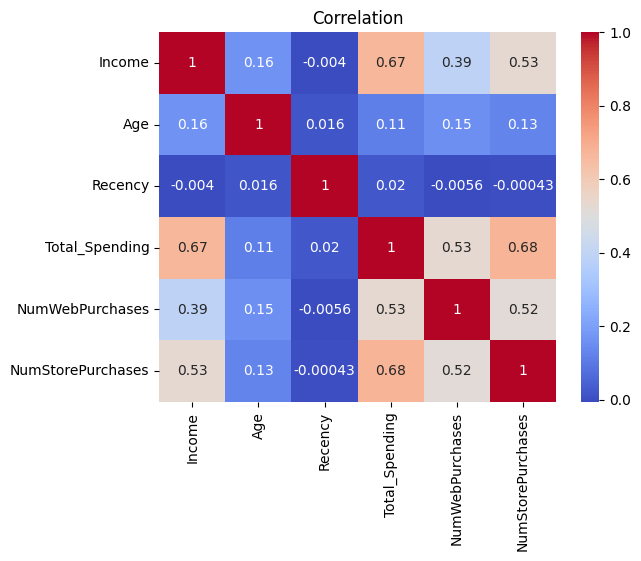

In [155]:
corr = data[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation")
plt.show()

Text(0.5, 1.0, 'Average Income by Education and Marital Status')

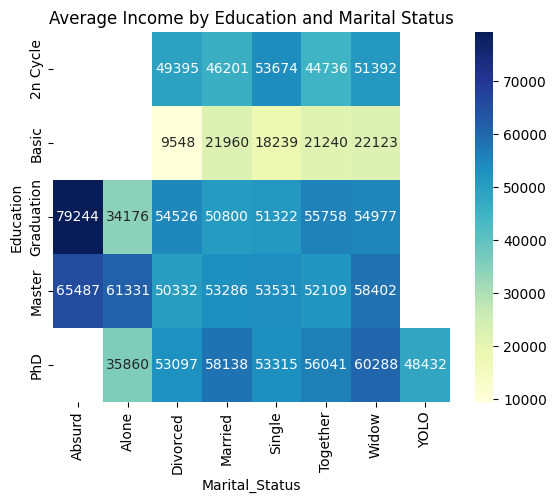

In [156]:
pivot_income = data.pivot_table(values = "Income", index= "Education", columns="Marital_Status", aggfunc= "mean")

sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap= "YlGnBu")
plt.title("Average Income by Education and Marital Status")

In [157]:
group1 = data.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

In [158]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

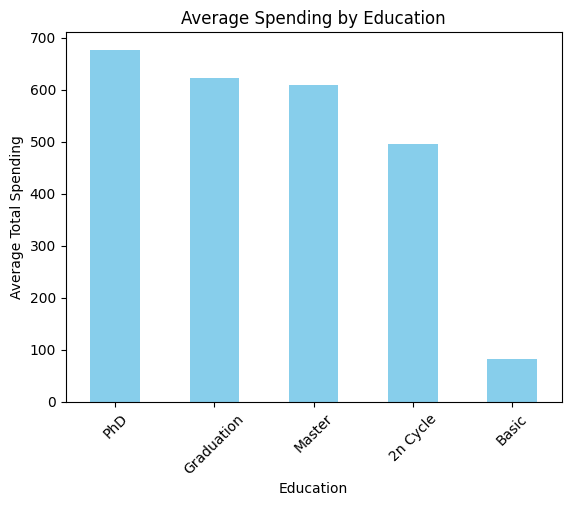

In [159]:
group1.plot(kind="bar", color = "skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 45)
plt.show()

In [160]:
data["AcceptedAny"] = data[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [161]:
data["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [162]:
data["AcceptedAny"] = data["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)
data["AcceptedAny"].unique()

array([1, 0])

In [163]:
group2 = data.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending= False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

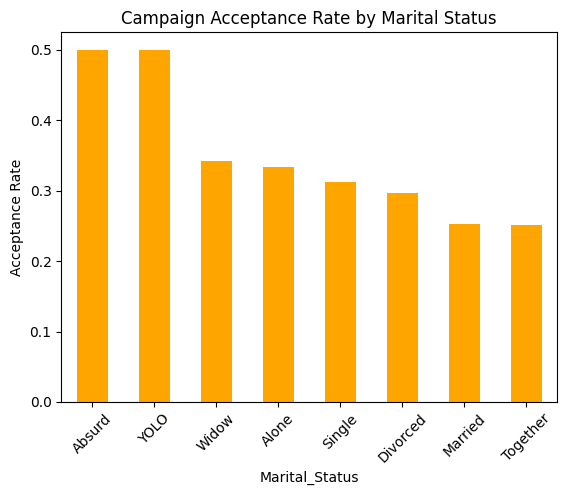

In [164]:
group2.plot(kind="bar", color= "orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation = 45)
plt.show()

In [165]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
data["AgeGroup"] = pd.cut(data["Age"], bins = bins, labels = labels)
data["AgeGroup"]

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [166]:
group3 = data.groupby("AgeGroup")["Income"].mean()
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

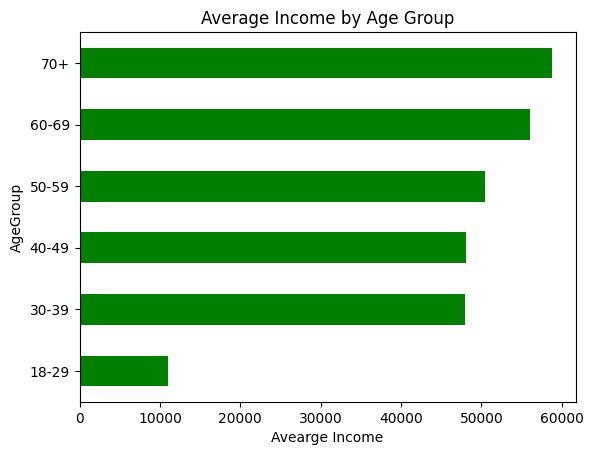

In [167]:
group3.plot(kind="barh", color = "green")
plt.title("Average Income by Age Group")
plt.xlabel("Avearge Income")
plt.show()

In [168]:
# Filtering The Data

features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]
X = data[features].copy()
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [169]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [170]:
# Elbow Method

from sklearn.cluster import KMeans

wc = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wc.append(kmeans.inertia_)

wc

[10218.620143748783,
 9007.769562675738,
 8239.376314881863,
 7567.674523392852,
 7094.735507620523,
 6732.037199508365,
 6166.091514736061,
 5855.106375385897]

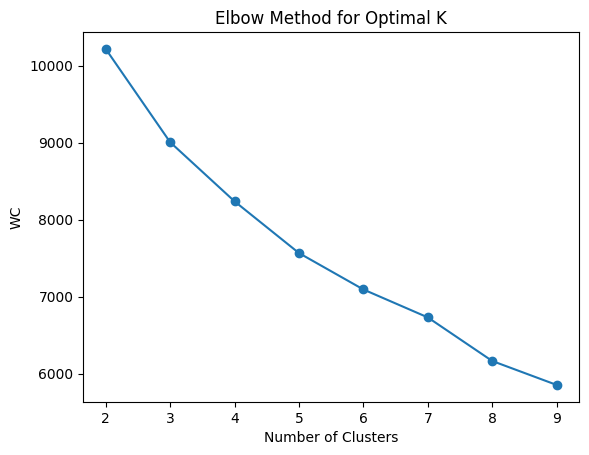

In [171]:
plt.plot(range(2,10),wc,marker= "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WC")
plt.show()

In [172]:
# Prediction

kmeans = KMeans(n_clusters = 4, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)
data["Cluster"]

0       3
1       0
2       3
3       0
4       2
       ..
2235    3
2236    3
2237    1
2238    1
2239    0
Name: Cluster, Length: 2216, dtype: int32

In [173]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0,1617,4945,1,60-69,3
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2,27,4395,0,70+,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0,776,4594,0,60-69,3
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1,53,4421,0,40-49,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1,422,4443,0,40-49,2


In [174]:
# Cluster Summary

cluster_summary = data.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,53.241319,34393.715278,117.152778,2.184028,3.315972,6.538194,24.838542
1,58.015254,77137.727119,1270.849153,4.440678,8.428814,2.432203,51.676271
2,56.749077,36715.747232,136.258303,2.416974,3.496310,6.357934,75.238007
3,61.133858,60153.415354,893.988189,7.608268,8.025591,6.181102,45.348425


In [175]:
# Add cluster size
cluster_counts = data["Cluster"].value_counts().sort_index()
cluster_summary["Count"] = cluster_counts

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

               Age        Income  ...    Recency  Count
Cluster                           ...                  
0        53.241319  34393.715278  ...  24.838542    576
1        58.015254  77137.727119  ...  51.676271    590
2        56.749077  36715.747232  ...  75.238007    542
3        61.133858  60153.415354  ...  45.348425    508

[4 rows x 8 columns]


In [176]:
# Normalized Comparison

cluster_summary_normalized  = cluster_summary.copy()

for col in features:
    cluster_summary_normalized[col] = (
        cluster_summary[col] - data[col].mean()
    ) / data[col].std()

print("\nNormalized Cluster Summary:\n")
print(cluster_summary_normalized)


Normalized Cluster Summary:

              Age    Income  Total_Spending  ...  NumWebVisitsMonth   Recency  Count
Cluster                                      ...                                    
0       -0.328586 -0.709231       -0.812609  ...           0.502668 -0.835077    576
1        0.069722  0.988774        1.100967  ...          -1.190273  0.092013    590
2       -0.035920 -0.616989       -0.780920  ...           0.428345  0.905937    542
3        0.329918  0.314072        0.475888  ...           0.355436 -0.126578    508

[4 rows x 8 columns]


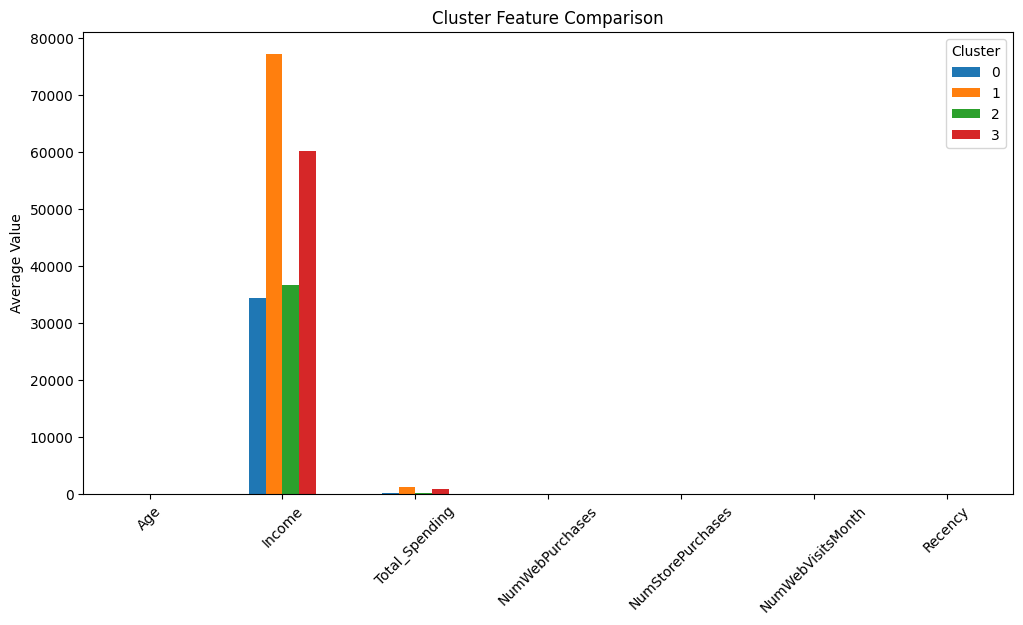

In [177]:
cluster_summary[features].T.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Feature Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

In [178]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
data["PCA1"], data["PCA2"] = pca_data[:,0], pca_data[:,1]

pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]], shape=(2216, 2))

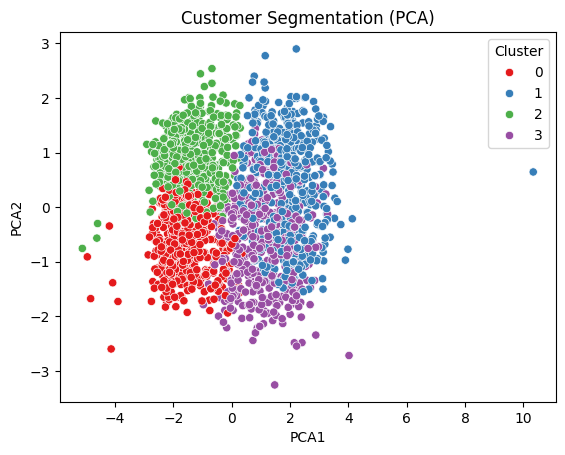

In [179]:
sns.scatterplot(x="PCA1", y="PCA2", hue = "Cluster", data = data, palette= "Set1")
plt.title("Customer Segmentation (PCA)")
plt.show()

In [180]:
print("\nCluster Counts:\n")
print(data["Cluster"].value_counts())


Cluster Counts:

Cluster
1    590
0    576
2    542
3    508
Name: count, dtype: int64


In [181]:
def label_cluster(row):

    if row["Income"] > data["Income"].mean() and row["Total_Spending"] > data["Total_Spending"].mean():
        return "High Value"
    elif row["Total_Spending"] < data["Total_Spending"].mean():
        return "Low Value"
    else:
        return "Mid Value"
    
data["Customer_Type"] = data.apply(label_cluster, axis=1)

print("\nCustomer Type Distribution:\n")
print(data["Customer_Type"].value_counts())



Customer Type Distribution:

Customer_Type
Low Value     1311
High Value     860
Mid Value       45
Name: count, dtype: int64
